In [11]:
import numpy as np
import sympy as sp

l1, l2, theta1, theta2 = sp.symbols('l1 l2 theta1 theta2')

T = sp.Matrix([
    [sp.cos(theta1), -sp.sin(theta1), l1*sp.cos(theta1)],
    [sp.sin(theta1),  sp.cos(theta1), l1*sp.sin(theta1)],
    [0,               0,              1                 ]
])

print(l1, l2, theta1, theta2)

# Addition for 5
t=sp.Symbol('t')
theta1= sp.Function('theta1')(t)
theta2= sp.Function('theta2')(t)

l1 l2 theta1 theta2


In [2]:
T01 = sp.Matrix([
    [sp.cos(theta1), -sp.sin(theta1), l1*sp.cos(theta1)],
    [sp.sin(theta1),  sp.cos(theta1), l1*sp.sin(theta1)],
    [0,               0,              1                 ]
])
T12 = sp.Matrix([
    [sp.cos(theta2), -sp.sin(theta2), l2*sp.cos(theta2)],
    [sp.sin(theta2),  sp.cos(theta2), l2*sp.sin(theta2)],
    [0,               0,              1                 ]
])

T02 = sp.simplify(T01 * T12)  # sympy handles the matrix multiplication


In [3]:
T02

Matrix([
[cos(theta1(t) + theta2(t)), -sin(theta1(t) + theta2(t)), l1*cos(theta1(t)) + l2*cos(theta1(t) + theta2(t))],
[sin(theta1(t) + theta2(t)),  cos(theta1(t) + theta2(t)), l1*sin(theta1(t)) + l2*sin(theta1(t) + theta2(t))],
[                         0,                           0,                                                 1]])

In [4]:
# Position of mass 1
pos1 = T01[:2, 2]  # first 2 rows, 3rd column
pose1 = sp.simplify(pos1)

# Position of mass 2
pos2 = T02[:2, 2]  # first 2 rows, 3rd column
pose2 = sp.simplify(pos2)

# Full pose (if needed) is just the whole matrix
#pose1 = T01
#pose2 = T02

In [19]:
pose1

Matrix([
[l1*cos(theta1(t))],
[l1*sin(theta1(t))]])

In [20]:
pose2

Matrix([
[l1*cos(theta1(t)) + l2*cos(theta1(t) + theta2(t))],
[l1*sin(theta1(t)) + l2*sin(theta1(t) + theta2(t))]])

In [6]:
# Body twist for mass 1
Vb1 = T01.inv() * sp.diff(T01, t)
wz1 = Vb1[1, 0]
vx1 = Vb1[0, 2]
vy1 = Vb1[1, 2]
Vb1_vec = sp.Matrix([wz1, vx1, vy1])
Vb1_vec = sp.simplify(Vb1_vec)

# Body twist for mass 2
Vb2 = T02.inv() * sp.diff(T02, t)
wz2 = Vb2[1, 0]
vx2 = Vb2[0, 2]
vy2 = Vb2[1, 2]
Vb2_vec = sp.Matrix([wz2, vx2, vy2])
Vb2_vec= sp.simplify(Vb2_vec)

In [7]:
Vb1_vec

Matrix([
[   Derivative(theta1(t), t)],
[                          0],
[l1*Derivative(theta1(t), t)]])

In [8]:
Vb2_vec

Matrix([
[                                                   Derivative(theta1(t), t) + Derivative(theta2(t), t)],
[                                                            l1*sin(theta2(t))*Derivative(theta1(t), t)],
[l1*cos(theta2(t))*Derivative(theta1(t), t) + l2*Derivative(theta1(t), t) + l2*Derivative(theta2(t), t)]])

In [22]:
from scipy.optimize import minimize

# Step 1: Create a lambda function for position of mass 2
# pos2 is already defined as T02[:2, 2] — convert it to a numeric function

pos2_func = sp.lambdify([theta1, theta2, l1, l2], pos2, 'numpy')

# Step 2: Define your link lengths (actual numbers now)
L1 = 1.0
L2 = 1.0

# Step 3: Define the IK cost function
# We want to find theta1, theta2 such that pos2_func == desired (x, y)
def ik_cost(thetas, x_des, y_des):
    th1, th2 = thetas
    pos = pos2_func(th1, th2, L1, L2)
    return (pos[0] - x_des)**2 + (pos[1] - y_des)**2

# Step 4: Solve for a desired position
x_desired = 1.5
y_desired = 0.5

result = minimize(ik_cost, x0=[0.1, 0.1], args=(x_desired, y_desired))

print("Found thetas:", result.x)
print("Converged:", result.success)

# Verify by plugging back in
th1_sol, th2_sol = result.x
print("Resulting position:", pos2_func(th1_sol, th2_sol, L1, L2))

Found thetas: [-0.33730687  1.31811569]
Converged: True
Resulting position: [[1.50000001]
 [0.5000007 ]]


In [71]:
#Problem 3
import numpy as np
#Generate Random valued Vectors
def random_rotation():
    theta = np.random.uniform(0,2*np.pi)
    n = np.random.randn(3)
    n = n/np.linalg.norm(n)
    nx, ny, nz = n
    nskew = np.array([
        [0, -nz, ny],
        [nz, 0, -nx],
        [-ny, nx, 0]
    ])
    I = np.eye(3)
    R = I + np.sin(theta)*nskew + (1 - np.cos(theta))*(nskew @ nskew)
    return R
R=random_rotation()
R
#To Double Check Math
#print(np.linalg.det(R))  # should be exactly 1.0
#print(R @ R.T)           # should be identity (1s on diagonal, 0s off)

array([[ 0.66029798,  0.25293932, -0.70712677],
       [-0.02398239,  0.94819713,  0.31677604],
       [ 0.75062069, -0.19220799,  0.63215874]])

In [80]:
# Problem 3 Part B
#Initialize
rotations=[]
for i in range(9):
    R=random_rotation()
    rotations.append(R)
    print(np.linalg.det(R))


1.0000000000000002
1.0
1.0
0.9999999999999998
1.0000000000000002
1.0
1.0
1.0000000000000004
0.9999999999999999


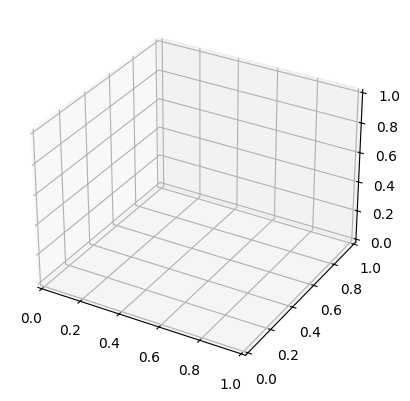

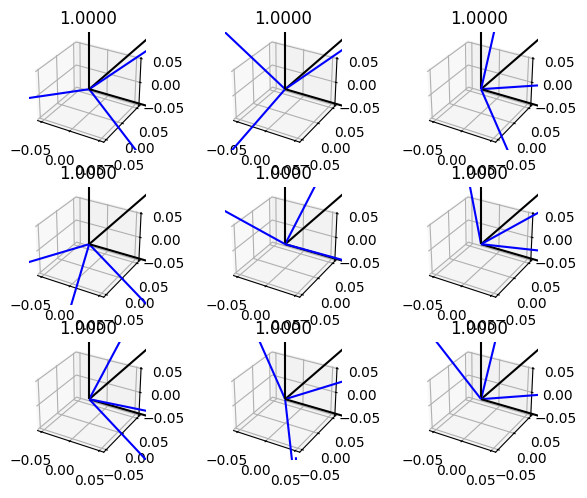

In [89]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')  # 111 means 1x1 grid, plot 1


def frame_plot(R, ax):  # add ax as parameter
    # World frame
    ax.quiver(0, 0, 0, 1, 0, 0, color='black')
    ax.quiver(0, 0, 0, 0, 1, 0, color='black')
    ax.quiver(0, 0, 0, 0, 0, 1, color='black')
    
    # Rotated frame
    ax.quiver(0, 0, 0, R[0,0], R[1,0], R[2,0], color='blue')
    ax.quiver(0, 0, 0, R[0,1], R[1,1], R[2,1], color='blue')
    ax.quiver(0, 0, 0, R[0,2], R[1,2], R[2,2], color='blue')
    ax.set_title(f"{np.linalg.det(R):.4f}")

# Create 3x3 figure
fig, axes = plt.subplots(3, 3, subplot_kw={'projection': '3d'})

for i in range(9):
    ax = axes[i//3, i%3]  # gets the right subplot position
    frame_plot(rotations[i], ax)

plt.tight_layout()
plt.show()
#frame_plot(rotations[0])